# Conditional Variational Autoencoder for Double Pendulum

Author: Jared Berry

VAE Template: Jueun Kwon

In [23]:
import sympy as sym
import numpy as np
import matplotlib.pyplot as plt

import torch # PyTorch
torch.manual_seed(10)
import torch.nn as nn # PyTorch for neural networks
from tqdm import tqdm

In [24]:
device = torch.device("cuda:2")
print(f'device: {device}')

device: cuda:2


In [25]:
# ##############################################################################################
# # If you're using Google Colab, uncomment this section by selecting the whole section and press
# # ctrl+'/' on your and keyboard. Run it before you start programming, this will enable the nice
# # LaTeX "display()" function for you. If you're using the local Jupyter environment, leave it alone
# ##############################################################################################
# def custom_latex_printer(exp,**options):
#     from google.colab.output._publish import javascript
#     url = "https://cdnjs.cloudflare.com/ajax/libs/mathjax/3.1.1/latest.js?config=TeX-AMS_HTML"
#     javascript(url=url)
#     return sym.printing.latex(exp,**options)
# sym.init_printing(use_latex="mathjax",latex_printer=custom_latex_printer)

In [26]:
def integrate(f, xt, dt):
    """
    This function takes in an initial condition x(t) and a timestep dt,
    as well as a dynamical system f(x) that outputs a vector of the
    same dimension as x(t). It outputs a vector x(t+dt) at the future
    time step.

    Parameters
    ============
    dyn: Python function
        derivate of the system at a given step x(t),
        it can considered as \dot{x}(t) = func(x(t))
    xt: NumPy array
        current step x(t)
    dt:
        step size for integration

    Return
    ============
    new_xt:
        value of x(t+dt) integrated from x(t)
    """
    k1 = dt * f(xt)
    k2 = dt * f(xt+k1/2.)
    k3 = dt * f(xt+k2/2.)
    k4 = dt * f(xt+k3)
    new_xt = xt + (1/6.) * (k1+2.0*k2+2.0*k3+k4)
    return new_xt

def simulate(f, x0, tspan, dt, integrate):
    """
    This function takes in an initial condition x0, a timestep dt,
    a time span tspan consisting of a list [min_time, max_time],
    as well as a dynamical system f(x) that outputs a vector of the
    same dimension as x0. It outputs a full trajectory simulated
    over the time span of dimensions (xvec_size, time_vec_size).

    Parameters
    ============
    f: Python function
        derivate of the system at a given step x(t),
        it can considered as \dot{x}(t) = func(x(t))
    x0: NumPy array
        initial conditions
    tspan: Python list
        tspan = [min_time, max_time], it defines the start and end
        time of simulation
    dt:
        time step for numerical integration
    integrate: Python function
        numerical integration method used in this simulation

    Return
    ============
    x_traj:
        simulated trajectory of x(t) from t=0 to tf
    """
    N = int((max(tspan)-min(tspan))/dt)
    x = np.copy(x0)
    tvec = np.linspace(min(tspan),max(tspan),N)
    xtraj = np.zeros((len(x0),N))
    for i in range(N):
        xtraj[:,i]=integrate(f,x,dt)
        x = np.copy(xtraj[:,i])
    return xtraj

In [27]:
from IPython.core.display import HTML
display(HTML("<table><tr><td><img src='https://github.com/MuchenSun/ME314pngs/raw/master/dyndoublepend.png' width=500' height='350'></table>"))

In [28]:
t, g, m1, m2, R1, R2 = sym.symbols(r't, g, m_1, m_2, R_1, R_2')

th1 = sym.Function(r'\theta_1')(t)
th2 = sym.Function(r'\theta_2')(t)
q = sym.Matrix([th1, th2])
qdot = q.diff(t)
qddot = qdot.diff(t)

# Pendulum m1
x1 = R1 * sym.sin(th1)
y1 = -R1 * sym.cos(th1)
x1dot = x1.diff(t)
y1dot = y1.diff(t)

# Pendulum m2
x2 = x1 + R2 * sym.sin(th1 + th2)
y2 = y1 - R2 * sym.cos(th1 + th2)
x2dot = x2.diff(t)
y2dot = y2.diff(t)

# Calculate Energies
KE1 = (1/2) * m1 * (x1dot**2 + y1dot**2)
KE2 = (1/2) * m2 * (x2dot**2 + y2dot**2)
PE1 = m1 * g * y1
PE2 = m2 * g * y2
KE = KE1 + KE2
PE = PE1 + PE2

# Calculate Lagrangian
L = KE - PE

# Euler-Lagrange for q where q = [theta_1, theta_2]
L = sym.Matrix([L])
dLdq = L.jacobian(q).T
dLdqdot = L.jacobian(qdot).T
d_dLdqdot_dt = dLdqdot.diff(t)
el_eqns = sym.Eq(sym.simplify(d_dLdqdot_dt - dLdq), sym.Matrix([0, 0]))
# print('Euler-Lagrange Equations:')
# display(sym.simplify(el_eqns))

soln = sym.solve(el_eqns, qddot)
th1ddot_soln = soln[qddot[0]]
th2ddot_soln = soln[qddot[1]]

subs_dict = {m1:1, m2:2, R1:2, R2:1, g:9.8}
th1ddot_soln = th1ddot_soln.subs(subs_dict)
th2ddot_soln = th2ddot_soln.subs(subs_dict)
th1ddot_func = sym.lambdify([q[0], q[1], qdot[0], qdot[1]], th1ddot_soln)
th2ddot_func = sym.lambdify([q[0], q[1], qdot[0], qdot[1]], th2ddot_soln)
# s0 = np.array([-np.pi/2, -np.pi/2, 0, 0])

def dyn(s):
  return np.array([
      s[2],
      s[3],
      th1ddot_func(*s),
      th2ddot_func(*s)
      ])

In [29]:
# Generate 1 trajectory
# T = 5
# dt = 0.01
# N = T / dt
# s0 = np.array([-np.pi/2, -np.pi/2, 0, 0])
# traj = simulate(dyn, s0, [0, T], dt, integrate)[0:2]
# print('Shape of traj: ', traj.shape)

## Dataset Generation:

In [30]:
# num_sampls = 3000  # Each trajectory is treated as a sample

# T = 5
# dt = 0.01
# N = int(T / dt)

# input_dim = 2 # Two dimensions (angles: theta_1 and theta_2) per time step
# seq_length = N  # Sequence length (number of time steps)
# hidden_dim = 256
# latent_dim = 2
# num_layers = 2

# learning_rate = 1e-3 # was 1e-3 before
# epochs = 50

In [31]:
num_samples = 10000  # Each trajectory is treated as a sample

T = 5
dt = 0.01
N = int(T / dt)

input_dim = 2 # Two dimensions (angles: theta_1 and theta_2) per time step
seq_length = N  # Sequence length (number of time steps)
hidden_dim = 256
latent_dim = 2
num_layers = 2

batch_size = 100
learning_rate = 1e-4 # was 1e-3 before
epochs = 50

In [32]:
# Generate N trajectories as training data
trajectories = []
for _ in tqdm(range(num_samples)):
    s0 = np.random.uniform(-np.pi/4, np.pi/4, size=1)  # Random initial state
    s0 = np.concatenate([np.array([-np.pi/3]), s0, np.array([0.0, 0.0])])  # [theta_1, theta_2, theta_1_dot, theta_2_dot]
    # s0 = np.array([-np.pi/2, -np.pi/2, 0, 0])
    traj = simulate(dyn, s0, [0, T], dt, integrate)[0:2]
    trajectories.append(traj.T)  # Transpose to (seq_length, input_dim)

# Load trajectory dataset
trajectories = np.array(trajectories)  # Shape: (batch_size, seq_length, input_dim)
trajectories = torch.tensor(trajectories, dtype=torch.float32).to(device)  # Shape: (batch_size, seq_length, input_dim)
data = torch.utils.data.DataLoader(trajectories, batch_size=batch_size, shuffle=True)


100%|██████████| 10000/10000 [07:53<00:00, 21.11it/s]


Debugging to make sure trajectories for th1 and th2 and decoupled and not flattened

In [33]:
print("Shape of trajectories (NumPy):", trajectories.shape)

for batch in data:
    print("Shape of one batch from DataLoader:", batch.size())  # Should be (batch_size, seq_length, input_dim)
    break

num_batches = len(data)
print(f"Number of batches: {num_batches}")


Shape of trajectories (NumPy): torch.Size([10000, 500, 2])
Shape of one batch from DataLoader: torch.Size([100, 500, 2])
Number of batches: 100


## Use multi-layer Gated Recurrent Unit (GRU) RNN

In [34]:
# I want to handle sequential data by maintaining temporal dependencies in the input, which is essential for my pendulum's trajectory data (theta 1 and theta 2)

class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, num_layers):
        super(Encoder, self).__init__()

        # Multi-layer GRU
        self.gru = nn.GRU(
            input_dim,  # Input feature size (e.g., 2 for theta_1 and theta_2)
            hidden_dim,  # Hidden state size
            num_layers,  # Number of stacked GRU layers
            batch_first=True  # Input shape: (batch_size, seq_length, feature_dim)
        )

        # Fully connected layers for mean and variance
        self.layer_mean = nn.Linear(hidden_dim, latent_dim)
        self.layer_var = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        """
        x shape: (batch_size, seq_length, input_dim)
        """
        # Pass input through GRU
        # h_n shape: (num_layers, batch_size, hidden_dim)
        _, h_n = self.gru(x)

        # Use the last hidden state from the top GRU layer
        # h_n[-1] selects the hidden state of the last layer
        h_n_last = h_n[-1]  # Shape: (batch_size, hidden_dim)

        # Compute mean and variance
        z_mean = self.layer_mean(h_n_last)  # Shape: (batch_size, latent_dim)
        z_log_var = self.layer_var(h_n_last)  # Shape: (batch_size, latent_dim)

        return z_mean, z_log_var



In [35]:
# The decoded trajectories will be conditioned on an initial condition, allowing us to generate trajectories
# by specifying intial angles and velocities.
class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim, cond_dim, num_layers, seq_length):
        super(Decoder, self).__init__()

        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        self.seq_length = seq_length
        self.output_dim = output_dim
        self.cond_dim = cond_dim

        # Linear layer to project the latent variable z and conditional variable y to the GRU's initial hidden state
        self.latent_to_hidden = nn.Linear(latent_dim + cond_dim, hidden_dim * num_layers)

        # GRU for reconstructing the sequence
        self.gru = nn.GRU(
            input_size=output_dim,  # Output is reconstructed at each time step
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        # Fully connected layer to map hidden states to output dimensions
        self.hidden_to_output = nn.Linear(hidden_dim, output_dim)

    def forward(self, z, y):
        """
        Parameters:
        z: Latent space variable, shape (batch_size, latent_dim)
        y: Conditional variable, shape (batch_size, cond_dim)

        Returns:
        x_hat: Reconstructed sequence, shape (batch_size, seq_length, output_dim)
        """

        # Project latent variable z to GRU's initial hidden state
        h_0 = self.latent_to_hidden(torch.concat([z, y], axis=1))  # Shape: (batch_size, hidden_dim * num_layers)
        h_0 = h_0.view(self.num_layers, -1, self.hidden_dim)  # Reshape to (num_layers, batch_size, hidden_dim)

        # Initialize the decoder's input sequence (all zeros for now)
        batch_size = z.size(0)
        x_input = torch.zeros((batch_size, self.seq_length, self.output_dim), device=z.device)

        # Pass through GRU
        gru_output, _ = self.gru(x_input, h_0)  # gru_output shape: (batch_size, seq_length, hidden_dim)

        # Map GRU outputs to trajectory dimensions
        x_hat = self.hidden_to_output(gru_output)  # Shape: (batch_size, seq_length, output_dim)

        return x_hat


In [36]:
class VariationalAutoEncoder(nn.Module):
    def __init__(self, encoder, decoder):
        super(VariationalAutoEncoder, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def reparameterization(self, mean, var):
        """
        Reparameterization trick to sample latent variable z
        using the mean and variance from the encoder.
        """
        epsilon = torch.randn_like(var).to(var.device)  # Ensure epsilon is on the same device
        z = mean + var * epsilon  # Reparameterization: z = mean + std * epsilon
        return z

    def forward(self, x, y):
        """
        Forward pass through the VAE.

        Parameters:
        x: Input sequence, shape (batch_size, seq_length, input_dim)
        y: Conditional variable corresponding to inptu sequence, shape (batch_size, cond_dim)

        Returns:
        x_hat: Reconstructed sequence, shape (batch_size, seq_length, output_dim)
        z_mean: Latent mean, shape (batch_size, latent_dim)
        z_log_var: Latent log-variance, shape (batch_size, latent_dim)
        """
        # Encode input to latent space
        z_mean, z_log_var = self.encoder(x)

        # Compute standard deviation from log-variance
        z_var = torch.exp(0.5 * z_log_var)  # Convert log-variance to standard deviation

        # Reparameterization to sample latent variable
        z = self.reparameterization(z_mean, z_var)

        # Decode latent variable back to reconstructed sequence
        x_hat = self.decoder(z, y)

        return x_hat, z_mean, z_log_var

In [37]:
encoder = Encoder(input_dim, hidden_dim, latent_dim, num_layers)
decoder = Decoder(latent_dim, hidden_dim, input_dim, input_dim, num_layers, seq_length) # Condition dimension is the same as input (theta1, theta2)
vae = VariationalAutoEncoder(encoder, decoder).to(device)

Latent variable value: tensor([[ 0.0448, -0.0463]], device='cuda:2', grad_fn=<AddmmBackward0>)


Exception ignored in: <function tqdm.__del__ at 0x7f5444441430>
Traceback (most recent call last):
  File "/home/jarmibe7/E2C/venv/lib/python3.8/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/jarmibe7/E2C/venv/lib/python3.8/site-packages/tqdm/notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


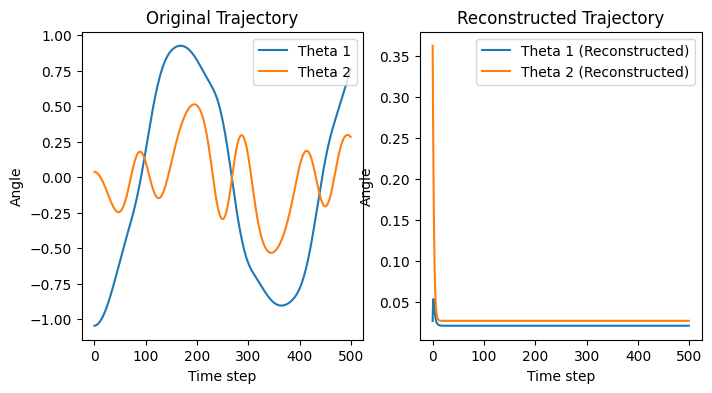

In [38]:
# Try data generation after the training
# (rerun the cell to generate a new sample)

for x in data:
    x = x.view(-1, seq_length, input_dim).to(device)  # Reshape to match the new encoder's input format
    x = x[0]  # Take the first trajectory from the batch
    y = x[0].unsqueeze(0)

    # Encode to get the latent variable (z_mean)
    test_z = vae.encoder(x.unsqueeze(0))[0]  # Add batch dimension and use the encoder
    print('Latent variable value:', test_z)

    # Decode z back to a trajectory
    test_x_hat = vae.decoder(test_z, y).squeeze(0).cpu().detach().numpy()  # Remove batch dimension
    break

# Plot the original and reconstructed trajectories
fig, axes = plt.subplots(1, 2, figsize=(8, 4), dpi=100)

# Original trajectory
ax = axes[0]
ax.set_title('Original Trajectory')
ax.plot(x.cpu().detach().numpy()[:, 0], label='Theta 1')  # Theta 1 (original)
ax.plot(x.cpu().detach().numpy()[:, 1], label='Theta 2')  # Theta 2 (original)
ax.set_xlabel('Time step')
ax.set_ylabel('Angle')
ax.legend()

# Reconstructed trajectory
ax = axes[1]
ax.set_title('Reconstructed Trajectory')
ax.plot(test_x_hat[:, 0], label='Theta 1 (Reconstructed)')  # Theta 1 (reconstructed)
ax.plot(test_x_hat[:, 1], label='Theta 2 (Reconstructed)')  # Theta 2 (reconstructed)
ax.set_xlabel('Time step')
ax.set_ylabel('Angle')
ax.legend()

plt.show()


In [39]:
# Define loss function (ELBO)
def kl_gaussian(mean, log_var):
    """
    KL divergence between a given Gaussian and the standard Gaussian (the assumed distribution of the latent variable)
    """
    return 0.5 * torch.sum(-log_var - 1.0 + torch.exp(log_var) + torch.square(mean))

def loss_function(x, x_hat, z_mean, z_log_var):
    log_likelihood = -1.0 * nn.functional.mse_loss(x_hat, x, reduction='mean') * 1e04
    kl_div = kl_gaussian(z_mean, z_log_var)
    elbo = log_likelihood - 1*kl_div
    # print('x:', x)
    # print('x_hat:', x_hat)
    # print('z_mean:', z_mean)
    # print('z_log_var:', z_log_var)
    # print(f"log_likelihood: {log_likelihood}, kl_div: {kl_div}")
    return -1.0 * elbo  # minimize negaive elbo = maximize elbo

In [40]:
# training the VAE
optimizer = torch.optim.Adam(vae.parameters(), lr=learning_rate)

vae.train()

for epoch in tqdm(range(epochs)):
    overall_loss = 0.0
    for batch_idx in data:
        # Reshape the data to (batch_size, seq_length, input_dim)
        batch_idx = batch_idx.view(-1, seq_length, input_dim).to(device)
        y = batch_idx[:, 0]

        optimizer.zero_grad()
        x_hat, z_mean, z_log_var = vae(batch_idx, y)
        loss = loss_function(batch_idx, x_hat, z_mean, z_log_var)
        overall_loss += loss.item()

        loss.backward()
        optimizer.step()

        # break

    # Print epoch summary
    print('Epoch ({:2d}/{:2d}) complete  |  ELBO: {:.4f}'.format(epoch + 1, epochs, -overall_loss / len(data.dataset)))
    # break


  2%|▏         | 1/50 [00:03<02:28,  3.04s/it]

Epoch ( 1/50) complete  |  ELBO: -29.1169


  4%|▍         | 2/50 [00:05<02:23,  2.99s/it]

Epoch ( 2/50) complete  |  ELBO: -26.1404


  6%|▌         | 3/50 [00:08<02:19,  2.97s/it]

...

Epoch (48/50) complete  |  ELBO: -5.2937


 98%|█████████▊| 49/50 [02:26<00:03,  3.01s/it]

Epoch (49/50) complete  |  ELBO: -5.2697


100%|██████████| 50/50 [02:29<00:00,  2.99s/it]

Epoch (50/50) complete  |  ELBO: -5.2824


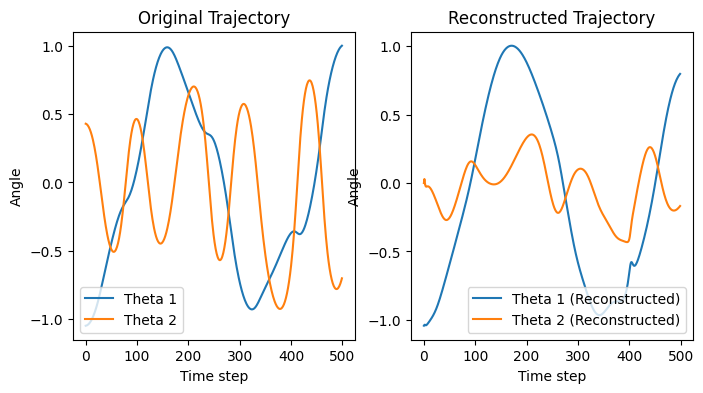

In [41]:
# Try data generation after the training
# (rerun the cell to generate a new sample)

for x in data:
    # Reshape input from (batch_size, input_dim) to (batch_size, seq_length, input_dim)
    x = x.view(-1, seq_length, input_dim).to(device)  # seq_length = 1000, input_dim = 2
    y = x[:, 0]

    # Encode to get latent variable (z_mean)
    test_z = vae.encoder(x)[0]  # Use the encoder to get z_mean
    # print('Latent variable value:', test_z)

    # Decode z back to a trajectory
    test_x_hat = vae.decoder(test_z, y).cpu().detach().numpy()  # Shape: (batch_size, seq_length, input_dim)
    break

# Extract the first trajectory from the batch for plotting
x_original = x[0].cpu().detach().numpy()  # Shape: (seq_length, input_dim)
x_reconstructed = test_x_hat[0]           # Shape: (seq_length, input_dim)

# Plot the original and reconstructed trajectories
fig, axes = plt.subplots(1, 2, figsize=(8, 4), dpi=100)

# Original trajectory
ax = axes[0]
ax.set_title('Original Trajectory')
ax.plot(x_original[:, 0], label='Theta 1')  # Theta 1 (original)
ax.plot(x_original[:, 1], label='Theta 2')  # Theta 2 (original)
ax.set_xlabel('Time step')
ax.set_ylabel('Angle')
ax.legend()

# Reconstructed trajectory
ax = axes[1]
ax.set_title('Reconstructed Trajectory')
ax.plot(x_reconstructed[:, 0], label='Theta 1 (Reconstructed)')  # Theta 1 (reconstructed)
ax.plot(x_reconstructed[:, 1], label='Theta 2 (Reconstructed)')  # Theta 2 (reconstructed)
ax.set_xlabel('Time step')
ax.set_ylabel('Angle')
ax.legend()

plt.show()


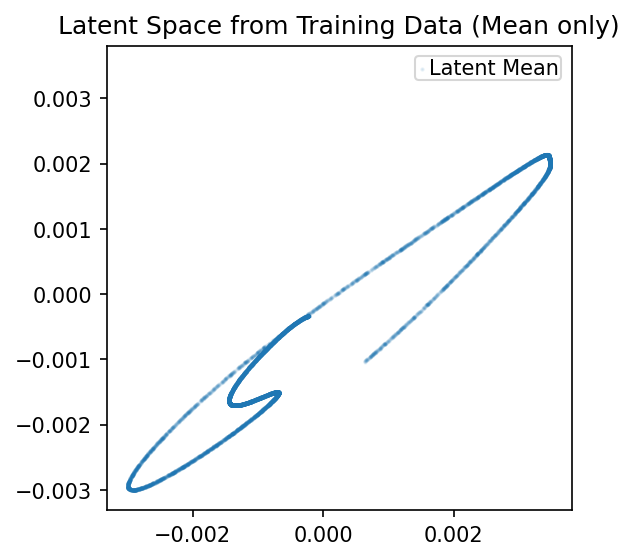

In [42]:
### Visualize the latent space

fig, ax = plt.subplots(1, 1, figsize=(4, 4), dpi=150, tight_layout=True)
ax.set_aspect('equal')
ax.set_title('Latent Space from Training Data (Mean only)')

latent_array = []

# Iterate over the DataLoader
for x in data:
    x = x.to(device)  # Input shape: (batch_size, seq_length, input_dim)
    z_mean = vae.encoder(x)[0]  # Extract the mean (z_mean) from the encoder
    latent_array.append(z_mean.cpu().detach().numpy())  # Store the mean

# Combine all latent means
latent_array = np.vstack(latent_array)  # Shape: (num_samples, latent_dim)

# Scatter plot of latent means
sc = ax.scatter(latent_array[:, 0], latent_array[:, 1], marker='o', s=1, alpha=0.1, label="Latent Mean")

# Set plot limits
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
a_min = min(x_min, y_min)
a_max = max(x_max, y_max)
ax.set_xlim(a_min, a_max)
ax.set_ylim(a_min, a_max)

# Add legend and display
ax.legend(loc='upper right', handletextpad=0.1, borderpad=0.1, labelspacing=0.2, handlelength=0.5)
plt.show()
plt.close()


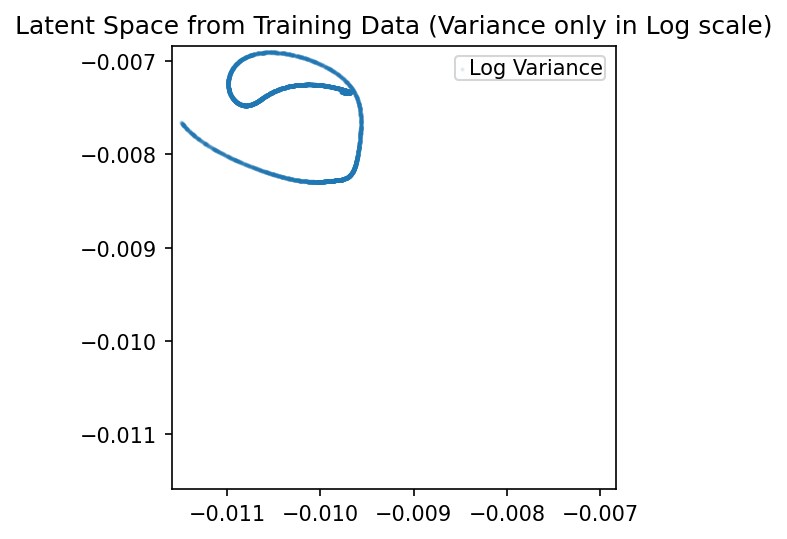

In [43]:
### Visualize the latent space

fig, ax = plt.subplots(1, 1, figsize=(4, 4), dpi=150, tight_layout=True)
ax.set_aspect('equal')
ax.set_title('Latent Space from Training Data (Variance only in Log scale)')

latent_array = []

# Iterate over the DataLoader
for x in data:
    x = x.to(device)  # Input shape: (batch_size, seq_length, input_dim)
    z_log_var = vae.encoder(x)[1]  # Extract log variance from encoder
    latent_array.append(z_log_var.cpu().detach().numpy())  # Store log variance

# Combine all latent log variances
latent_array = np.vstack(latent_array)  # Shape: (num_samples, latent_dim)

# Scatter plot of log variances
sc = ax.scatter(latent_array[:, 0], latent_array[:, 1], marker='o', s=1, alpha=0.1, label="Log Variance")

# Set plot limits
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
a_min = min(x_min, y_min)
a_max = max(x_max, y_max)
ax.set_xlim(a_min, a_max)
ax.set_ylim(a_min, a_max)

# Add legend and display
ax.legend(loc='upper right', handletextpad=0.1, borderpad=0.1, labelspacing=0.2, handlelength=0.5)
plt.show()
plt.close()


In [44]:
# # Visualize latent space considering mean and variance
# fig, ax = plt.subplots(1, 1, figsize=(4, 4), dpi=150, tight_layout=True)
# ax.set_aspect('equal')
# ax.set_title('Latent Space from Training Data (Mean and Variance)')

# latent_mean = []
# latent_var = []

# # Iterate over DataLoader
# for x in data:
#     x = x.to(device)  # Input shape: (batch_size, seq_length, input_dim)
#     z_mean, z_log_var = vae.encoder(x)  # Get mean and log variance
#     latent_mean.append(z_mean)
#     latent_var.append(torch.exp(z_log_var))  # Convert log variance to variance

#     # Convert to numpy for scatter plot
#     z_mean_np = z_mean.cpu().detach().numpy()
#     z_var_np = torch.exp(z_log_var).cpu().detach().numpy()

#     # Represent uncertainty by point size
#     point_sizes = np.mean(z_var_np, axis=1) * 100  # Adjust scaling as needed
#     sc = ax.scatter(z_mean_np[:, 0], z_mean_np[:, 1], s=point_sizes, alpha=0.1, label=None)

# # Combine all latent means and variances
# latent_mean = torch.cat(latent_mean).cpu().detach().numpy()
# latent_var = torch.cat(latent_var).cpu().detach().numpy()

# # Adjust plot limits
# x_min, x_max = ax.get_xlim()
# y_min, y_max = ax.get_ylim()
# a_min = np.minimum(x_min, y_min)
# a_max = np.maximum(x_max, y_max)
# ax.set_xlim(a_min, a_max)
# ax.set_ylim(a_min, a_max)

# plt.show()
# plt.close()


In [45]:
# # Visualize latent space with sampled points from the Gaussian distribution
# fig, ax = plt.subplots(1, 1, figsize=(4, 4), dpi=150, tight_layout=True)
# ax.set_aspect('equal')
# ax.set_title('Latent Space with Gaussian Samples')

# latent_mean = []
# latent_var = []

# # Iterate over DataLoader
# for x in data:
#     x = x.to(device)  # Input shape: (batch_size, seq_length, input_dim)
#     z_mean, z_log_var = vae.encoder(x)  # Get latent mean and log variance
#     latent_mean.append(z_mean)
#     latent_var.append(torch.exp(z_log_var))  # Convert log variance to variance

#     # Sample from the Gaussian distribution
#     z_sampled = z_mean + torch.randn_like(z_mean) * torch.sqrt(torch.exp(z_log_var))

#     # Convert to numpy for scatter plot
#     z_mean_np = z_mean.cpu().detach().numpy()
#     z_sampled_np = z_sampled.cpu().detach().numpy()

#     # Plot sampled points
#     ax.scatter(z_sampled_np[:, 0], z_sampled_np[:, 1], marker='o', s=5, alpha=0.1, label=None)

# # Combine all latent means and variances
# latent_mean = torch.cat(latent_mean).cpu().detach().numpy()
# latent_var = torch.cat(latent_var).cpu().detach().numpy()

# # Adjust plot limits
# x_min, x_max = ax.get_xlim()
# y_min, y_max = ax.get_ylim()
# a_min = np.minimum(x_min, y_min)
# a_max = np.maximum(x_max, y_max)
# ax.set_xlim(a_min, a_max)
# ax.set_ylim(a_min, a_max)

# plt.show()
# plt.close()


A good latent space should look like a funzzy uniformly distributed ball, and it does! Yay!

In [47]:
### Generate new data
### (rerun the cell to generate new sample)
### ! Note that we only need the trained decoder now

latent_mean = torch.mean(torch.tensor(latent_array), dim=0)
latent_cov = torch.cov(torch.tensor(latent_array).T)
x0 = np.array([-np.pi/3, 0.0])
x0_tens = torch.from_numpy(x0).to(torch.float32).to(device).unsqueeze(0)

# Sample a new latent variable from the learned latent distribution
new_z = torch.distributions.MultivariateNormal(loc=latent_mean, covariance_matrix=latent_cov).sample().to(device)
print('New latent variable: ', new_z)

# Decode the sampled latent variable to generate new data
new_x = vae.decoder(new_z.unsqueeze(0), x0_tens).cpu().detach().numpy().reshape((seq_length, input_dim))
new_z = new_z.cpu().detach().numpy()

# # Plot latent space and new data
# fig, axes = plt.subplots(1, 2, figsize=(8, 4), dpi=150, tight_layout=True)

# # Plot the latent space with the new latent variable
# ax = axes[0]
# ax.set_title("Cross is the new latent variable")
# for x in data:
#     x = x.to(device)  # Input shape: (batch_size, seq_length, input_dim)
#     z = vae.encoder(x)[0]  # Extract latent mean
#     z = z.cpu().detach().numpy()
#     sc = ax.scatter(z[:, 0], z[:, 1], marker='o', s=1, alpha=0.1, label=None)
# ax.plot(new_z[0], new_z[1], marker='x', markersize=10, color='k')  # Mark new latent variable
# x_min, x_max = ax.get_xlim()
# y_min, y_max = ax.get_ylim()
# a_min = np.minimum(x_min, y_min)
# a_max = np.maximum(x_max, y_max)
# ax.set_xlim(a_min, a_max)
# ax.set_ylim(a_min, a_max)

# # Display re-generated data (trajectory)
# ax = axes[1]
# ax.set_title("Re-Generated Data")
# ax.plot(new_x[:, 0], label='Theta 1')  # Re-generated trajectory for Theta 1
# ax.plot(new_x[:, 1], label='Theta 2')  # Re-generated trajectory for Theta 2
# ax.set_xlabel('Time step')
# ax.set_ylabel('Angle')
# ax.legend()

# plt.show()
# plt.close()

# Simulate a trajectory from the same initial condition
x0_full = np.concatenate([x0, np.array([0.0, 0.0])])
traj_sim = simulate(dyn, x0_full, [0, T], dt, integrate)[0:2]

New latent variable:  tensor([-0.0106, -0.0072], device='cuda:2')


## Animate the reconstructed trajectory

In [ ]:
# # Plot
# plt.plot(np.arange(N)*dt, traj[0:2].T)
# plt.title(r'Trajectories of $\theta_1(t)$ and $\theta_2(t)$')
# plt.xlabel("time (s)")
# plt.legend((r'$\theta_1(t)$', r'$\theta_2(t)$'), loc='upper left')
# plt.show()

In [48]:
def animate_double_pend(theta_array,L1=1,L2=1,T=10):
    """
    Function to generate web-based animation of double-pendulum system

    Parameters:
    ================================================
    theta_array:
        trajectory of theta1 and theta2, should be a NumPy array with
        shape of (2,N)
    L1:
        length of the first pendulum
    L2:
        length of the second pendulum
    T:
        length/seconds of animation duration

    Returns: None
    """

    ################################
    # Imports required for animation.
    from plotly.offline import init_notebook_mode, iplot
    from IPython.display import display, HTML
    import plotly.graph_objects as go

    #######################
    # Browser configuration.
    def configure_plotly_browser_state():
        import IPython
        display(IPython.core.display.HTML('''
            <script src="/static/components/requirejs/require.js"></script>
            <script>
              requirejs.config({
                paths: {
                  base: '/static/base',
                  plotly: 'https://cdn.plot.ly/plotly-1.5.1.min.js?noext',
                },
              });
            </script>
            '''))
    configure_plotly_browser_state()
    init_notebook_mode(connected=False)

    ###############################################
    # Getting data from pendulum angle trajectories.
    xx1=L1*np.sin(theta_array[0])
    yy1=-L1*np.cos(theta_array[0])
    xx2=xx1+L2*np.sin(theta_array[0]+theta_array[1])
    yy2=yy1-L2*np.cos(theta_array[0]+theta_array[1])
    N = len(theta_array[0]) # Need this for specifying length of simulation

    ####################################
    # Using these to specify axis limits.
    xm=np.min(xx1)-0.5
    xM=np.max(xx1)+0.5
    ym=np.min(yy1)-2.5
    yM=np.max(yy1)+1.5

    ###########################
    # Defining data dictionary.
    # Trajectories are here.
    data=[dict(x=xx1, y=yy1,
               mode='lines', name='Arm',
               line=dict(width=2, color='blue')
              ),
          dict(x=xx1, y=yy1,
               mode='lines', name='Mass 1',
               line=dict(width=2, color='purple')
              ),
          dict(x=xx2, y=yy2,
               mode='lines', name='Mass 2',
               line=dict(width=2, color='green')
              ),
          dict(x=xx1, y=yy1,
               mode='markers', name='Pendulum 1 Traj',
               marker=dict(color="purple", size=2)
              ),
          dict(x=xx2, y=yy2,
               mode='markers', name='Pendulum 2 Traj',
               marker=dict(color="green", size=2)
              ),
        ]

    ################################
    # Preparing simulation layout.
    # Title and axis ranges are here.
    layout=dict(xaxis=dict(range=[xm, xM], autorange=False, zeroline=False,dtick=1),
                yaxis=dict(range=[ym, yM], autorange=False, zeroline=False,scaleanchor = "x",dtick=1),
                title='Double Pendulum Simulation',
                hovermode='closest',
                updatemenus= [{'type': 'buttons',
                               'buttons': [{'label': 'Play','method': 'animate',
                                            'args': [None, {'frame': {'duration': T, 'redraw': False}}]},
                                           {'args': [[None], {'frame': {'duration': T, 'redraw': False}, 'mode': 'immediate',
                                            'transition': {'duration': 0}}],'label': 'Pause','method': 'animate'}
                                          ]
                              }]
               )

    ########################################
    # Defining the frames of the simulation.
    # This is what draws the lines from
    # joint to joint of the pendulum.
    frames=[dict(data=[dict(x=[0,xx1[k],xx2[k]],
                            y=[0,yy1[k],yy2[k]],
                            mode='lines',
                            line=dict(color='red', width=3)
                            ),
                       go.Scatter(
                            x=[xx1[k]],
                            y=[yy1[k]],
                            mode="markers",
                            marker=dict(color="blue", size=12)),
                       go.Scatter(
                            x=[xx2[k]],
                            y=[yy2[k]],
                            mode="markers",
                            marker=dict(color="blue", size=12)),
                      ]) for k in range(N)]

    #######################################
    # Putting it all together and plotting.
    figure1=dict(data=data, layout=layout, frames=frames)
    iplot(figure1)

##################################################

In [49]:
# Simulation animation of the double-pendulum system
animate_double_pend(traj_sim, L1=2, L2=1, T=10)
animate_double_pend(new_x.T, L1=2, L2=1, T=10)

ModuleNotFoundError: No module named 'plotly'

## Afterthought

In this example, angles were used to train the vae. This is better than using the x and y coordinates because you get the geometry of the pendulum for free just from choosing a good state to model the problem in.